# Astra Study

[INFO] Inicializando Depth Anything V2 Small...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Buscando primer frame...


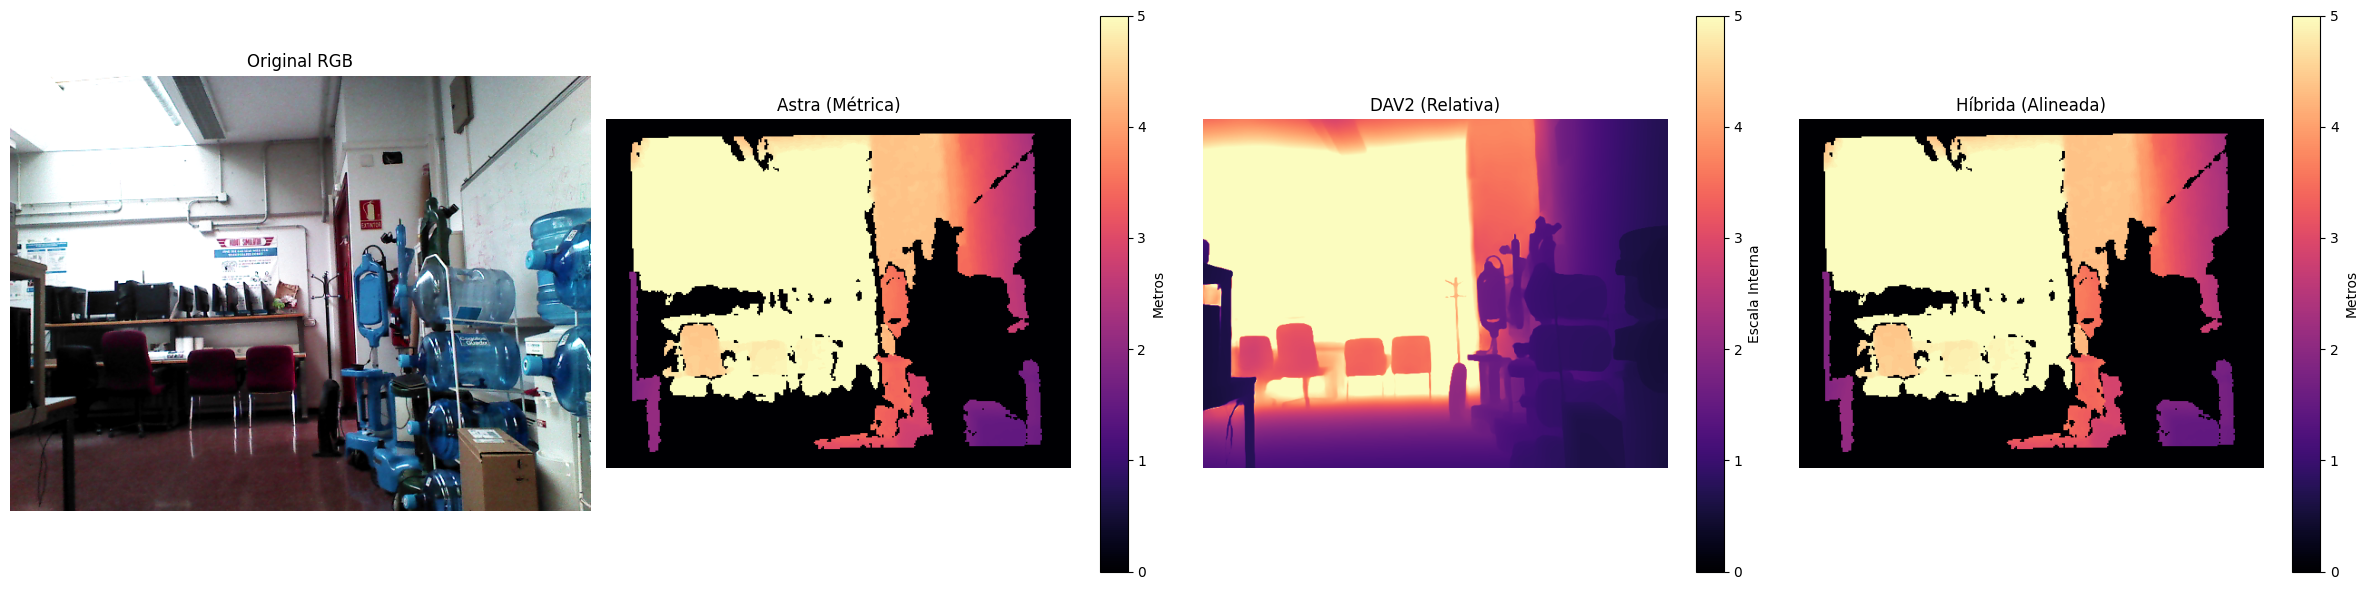

In [1]:
import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from rosbags.highlevel import AnyReader
from rosbags.typesys import Stores, get_typestore
from opensplat3d.data import OpenSplatFullPipeline, DepthStabilizer


# Asegúrate de tener la clase DepthStabilizer y OpenSplatFullPipeline cargadas o importadas
# (Puedes pegar las definiciones de las clases arriba de este bloque)

def visualize_first_frame(bag_path, pipeline):
    typestore = get_typestore(Stores.ROS2_HUMBLE)
    
    with AnyReader([Path(bag_path)], default_typestore=typestore) as reader:
        # 1. Identificar conexiones
        try:
            color_conn = [c for c in reader.connections if 'color' in c.topic][0]
            depth_conn = [c for c in reader.connections if 'depth' in c.topic][0]
        except IndexError:
            print("Error: No se encontraron los tópicos necesarios.")
            return

        # 2. Buscar el primer par de mensajes sincronizados
        print("Buscando primer frame...")
        c_msg, d_msg = None, None
        
        # Leemos mensajes de color
        for _, _, raw in reader.messages(connections=[color_conn]):
            c_msg = reader.deserialize(raw, color_conn.msgtype)
            c_ts = c_msg.header.stamp.sec + c_msg.header.stamp.nanosec * 1e-9
            
            # Buscamos el de profundidad más cercano
            for _, _, d_raw in reader.messages(connections=[depth_conn]):
                temp_d = reader.deserialize(d_raw, depth_conn.msgtype)
                d_ts = temp_d.header.stamp.sec + temp_d.header.stamp.nanosec * 1e-9
                
                if abs(d_ts - c_ts) < 0.05: # Umbral de sincronización
                    d_msg = temp_d
                    break
            if d_msg: break

        if c_msg is None or d_msg is None:
            print("No se encontró un par sincronizado.")
            return

        # 3. Procesar Imagen Color
        if "CompressedImage" in color_conn.msgtype:
            img = cv2.imdecode(np.frombuffer(c_msg.data, np.uint8), cv2.IMREAD_UNCHANGED)
        else:
            img = np.frombuffer(c_msg.data, np.uint8).reshape(c_msg.height, c_msg.width, 3)
            img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # 4. Procesar Profundidad Astra
        d_astra = np.frombuffer(d_msg.data, np.uint16).reshape(d_msg.height, d_msg.width).astype(np.float32) / 1000.0

        # 5. Generar Profundidad DAV2 (Relativa)
        inputs = pipeline.processor(images=img_rgb, return_tensors="pt").to(pipeline.device)
        with torch.no_grad():
            pred = pipeline.model(**inputs).predicted_depth
        
        # Redimensionar al tamaño original
        d_dav2_rel = torch.nn.functional.interpolate(
            pred.unsqueeze(1), size=img.shape[:2], mode="bicubic"
        ).squeeze().cpu().numpy()

        # 6. Alinear usando tu función del script
        d_ia, d_final = pipeline.align_depth(d_dav2_rel, d_astra)

        # --- VISUALIZACIÓN ---
        fig, axes = plt.subplots(1, 4, figsize=(24, 6))
        
        axes[0].imshow(img_rgb)
        axes[0].set_title("Original RGB")
        
        im1 = axes[1].imshow(d_astra, cmap='magma', vmin=0, vmax=5)
        axes[1].set_title("Astra (Métrica)")
        plt.colorbar(im1, ax=axes[1], label='Metros')
        
        im2 = axes[2].imshow(d_ia, cmap='magma', vmin=0, vmax=5)
        axes[2].set_title("DAV2 (Relativa)")
        plt.colorbar(im2, ax=axes[2], label='Escala Interna')
        
        im3 = axes[3].imshow(d_final, cmap='magma', vmin=0, vmax=5)
        axes[3].set_title("Híbrida (Alineada)")
        plt.colorbar(im3, ax=axes[3], label='Metros')

        for ax in axes: ax.axis('off')
        plt.tight_layout()
        plt.show()

# --- EJECUCIÓN ---
# Configura tus rutas y parámetros aquí
BAG_FILE = "/home/ubuntu/datasets/astra_lab/astra_lab_0.db3"
OUT_DIR = "/home/ubuntu/datasets/mapir_lab"

pipeline = OpenSplatFullPipeline(bag_path=BAG_FILE, out_dir=OUT_DIR)
visualize_first_frame(BAG_FILE, pipeline)

In [1]:
from rosbags.highlevel import AnyReader
from rosbags.typesys import Stores, get_typestore
from pathlib import Path

typestore = get_typestore(Stores.ROS2_HUMBLE)
with AnyReader([Path('/home/ubuntu/datasets/astra_lab/astra_lab_0.db3')], default_typestore=typestore) as reader:
    for c in reader.connections:
        print(c.topic, '->', c.msgtype)

/tf_static -> tf2_msgs/msg/TFMessage
/tf -> tf2_msgs/msg/TFMessage
/amcl_pose -> geometry_msgs/msg/PoseWithCovarianceStamped
/astra_camera/color/image_raw -> sensor_msgs/msg/Image
/astra_camera/depth/image_raw -> sensor_msgs/msg/Image
/odom -> nav_msgs/msg/Odometry


In [3]:
from pathlib import Path
from rosbags.highlevel import AnyReader
from rosbags.typesys import Stores, get_typestore
import pprint

def inspect_topic(bag_path, topic_name, num_msgs=2):
    """
    Lee e inspecciona cualquier topic de un ROS2 Bag directamente en el Notebook.
    """
    typestore = get_typestore(Stores.ROS2_HUMBLE)
    bag_file = Path(bag_path)
    
    if not bag_file.exists():
        print(f"❌ Error: El archivo {bag_path} no existe.")
        return

    with AnyReader([bag_file], default_typestore=typestore) as reader:
        connections = [c for c in reader.connections if c.topic == topic_name]
        
        if not connections:
            print(f"⚠️ Topic '{topic_name}' no encontrado.")
            print("\nTopics disponibles en este bag:")
            for c in sorted(reader.connections, key=lambda x: x.topic):
                print(f"  • {c.topic} ({c.msgtype})")
            return

        print(f"Leyendo {num_msgs} mensajes de '{topic_name}'...\n" + "="*50)
        
        count = 0
        for connection, timestamp, rawdata in reader.messages(connections=connections):
            msg = typestore.deserialize_cdr(rawdata, connection.msgtype)
            
            print(f"🔹 Mensaje #{count} | Timestamp: {timestamp}")
            
            # Función recursiva para convertir el mensaje a un diccionario legible
            def msg_to_dict(m):
                if hasattr(m, '__msgtype__'):
                    return {k: msg_to_dict(v) for k, v in m.__dict__.items() if not k.startswith('_')}
                elif isinstance(m, list):
                    return [msg_to_dict(x) for x in m]
                return m

            pprint.pprint(msg_to_dict(msg), indent=2, width=100)
            print("-" * 50)
            
            count += 1
            if count >= num_msgs:
                break

# --- CONFIGURACIÓN ---
BAG_PATH = "/home/ubuntu/datasets/astra_lab/astra_lab_0.db3"
TOPIC = "/amcl_pose"  # Cambia esto por el topic que quieras ver

# --- EJECUCIÓN ---
inspect_topic(BAG_PATH, TOPIC, num_msgs=1)


Leyendo 1 mensajes de '/amcl_pose'...
🔹 Mensaje #0 | Timestamp: 1776693030178701597
{ 'header': {'frame_id': 'map', 'stamp': {'nanosec': 877126014, 'sec': 1776692958}},
  'pose': { 'covariance': array([0.00649645, 0.00030452, 0.        , 0.        , 0.        ,
       0.        , 0.00030452, 0.0029139 , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.0009298 ]),
            'pose': { 'orientation': { 'w': 0.9990899689061152,
                                       'x': 0.0,
                                       'y': 0.0,
                                       'z': 0.042652479777590714},
                      'position': {'x': -7.147992826710875, 'y': 1.5465081081126573, '